In [2]:
# ============================================================
# CELL 1 — Install
# ============================================================
!pip install ultralytics -q
print("✅ Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00
✅ Done


In [3]:
# ============================================================
# CELL 2 — Upload Weights
# ============================================================
from google.colab import files
import shutil
from pathlib import Path

# The .pt file has already been uploaded.
# uploaded = files.upload()

WEIGHTS_PATH = Path("best_yolov8m_visdrone.pt")
print(f"✅ Weights ready → {WEIGHTS_PATH}")

✅ Weights ready → best_yolov8m_visdrone.pt


In [4]:
# ============================================================
# CELL 3 — Upload Test Images challening without label
# ============================================================
# Option A — if you have a zip file of test images
# The zip file has already been uploaded.
# uploaded = files.upload()  # upload your zip
!unzip -q test.zip -d test_images/
TEST_DIR = Path("test_images")

print(f"✅ Test images ready")
print(f"   Found: {len(list(TEST_DIR.glob('*.jpg')))} images")

✅ Test images ready
   Found: 1580 images


In [12]:
# ============================================================
# CELL 3.5 — Upload and Prepare New Test Data
# ============================================================
from pathlib import Path
import shutil

# Assuming 'test_label.zip' contains images and 'label.zip' contains their labels
# and both are uploaded to the /content/ directory.

# Create a new directory for the updated test data to avoid conflicts
NEW_TEST_DATA_ROOT = Path("new_test_data")
NEW_TEST_DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Unzip new test images into new_test_data/images
# The '/content/' prefix assumes the zips were uploaded directly to /content/
!unzip -q /content/test_label.zip -d {NEW_TEST_DATA_ROOT / "images"}/

# Unzip new labels into new_test_data/labels
# FIX: Changed path from /content/label.zip to /content/label/label.zip
!unzip -q /content/label/label.zip -d {NEW_TEST_DATA_ROOT / "labels"}/

# Update TEST_DIR to point to the new images directory
# This TEST_DIR will be used by subsequent cells (Cell 4, 5, etc.)
TEST_DIR = NEW_TEST_DATA_ROOT / "images"

print(f"✅ New test images ready at {TEST_DIR}")
print(f"   Found: {len(list(TEST_DIR.glob('*.jpg')))} images")
print(f"✅ New labels ready at {NEW_TEST_DATA_ROOT / 'labels'}")
print(f"   Found: {len(list((NEW_TEST_DATA_ROOT / 'labels').glob('*.txt')))} label files")

replace new_test_data/images/0000006_00159_d_0000001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ New test images ready at new_test_data/images
   Found: 1610 images
✅ New labels ready at new_test_data/labels
   Found: 1610 label files


In [7]:
# ============================================================
# CELL 4 — Load Model & Run on Test Set
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

# Settings
CLASS_NAMES = {0: "human", 1: "car"}
COLORS      = {0: (0, 255, 120), 1: (0, 120, 255)}
CONF_THRESH = 0.20
IOU_THRESH  = 0.45

# Load model
detector = YOLO(str(WEIGHTS_PATH))
print("✅ Model loaded")

# Get test images
test_images = sorted(TEST_DIR.glob("*.jpg"))
print(f"   Total test images: {len(test_images)}")

✅ Model loaded
   Total test images: 1580


In [3]:
# ============================================================
# CELL 5 — Extraction and Evaluation
# ============================================================
import yaml
import os
from pathlib import Path
from ultralytics import YOLO

# 1. Setup Paths
NEW_TEST_DATA_ROOT = Path("new_test_data")
NEW_TEST_DATA_ROOT.mkdir(parents=True, exist_ok=True)

# 2. Extract Data (since you re-uploaded)
print("⌛ Extracting new test data...")
!unzip -o -q /content/test_label.zip -d {NEW_TEST_DATA_ROOT / 'images'}/
!unzip -o -q /content/label.zip -d {NEW_TEST_DATA_ROOT / 'labels'}/

# 3. Define Settings
CONF_THRESH = 0.20
IOU_THRESH  = 0.45
WEIGHTS_PATH = "best_yolov8m_visdrone.pt"

# 4. Create YAML
yaml_data = {
    "path": str(NEW_TEST_DATA_ROOT.absolute()),
    "train": "images",
    "val": "images",
    "test": "images",
    "nc": 2,
    "names": ["human", "car"]
}
with open("test.yaml", "w") as f:
    yaml.dump(yaml_data, f)

# 5. Load Model and Run Evaluation
detector = YOLO(WEIGHTS_PATH)
metrics = detector.val(
    data="test.yaml",
    split="test",
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    verbose=True
)

# 6. Display Results
m = metrics.box
print(f"\n{'='*45}")
print("NEW TEST DATA RESULTS (1610 Images)")
print(f"{'='*45}")
print(f"Precision  : {float(m.mp):.4f}")
print(f"Recall     : {float(m.mr):.4f}")
print(f"mAP@0.50   : {float(m.map50):.4f}")
print(f"mAP@0.50:95: {float(m.map):.4f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⌛ Extracting new test data...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2899.9±886.4 MB/s, size: 211.9 KB)
val: Scanning /content/new_test_data/labels... 1609 images, 0 backgrounds, 1588 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 2.3Kit/s 0.7s
val: /content/new_test_data/images/0000006_00159_d_0000001.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 2. Possible class labels are 0-1
val: /content/new_test_data/images/0000006_00611_d_0000002.jpg: ignoring corrupt image/label: Label class 9 e

/tmp/ipykernel_1911/3290421322.py:35: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1911/3290421322.py:35: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1911/3290421322.py:36: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("test_results.png", dpi=120, bbox_inches="tight")
/tmp/ipykernel_1911/3290421322.py:36: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig("test_results.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.

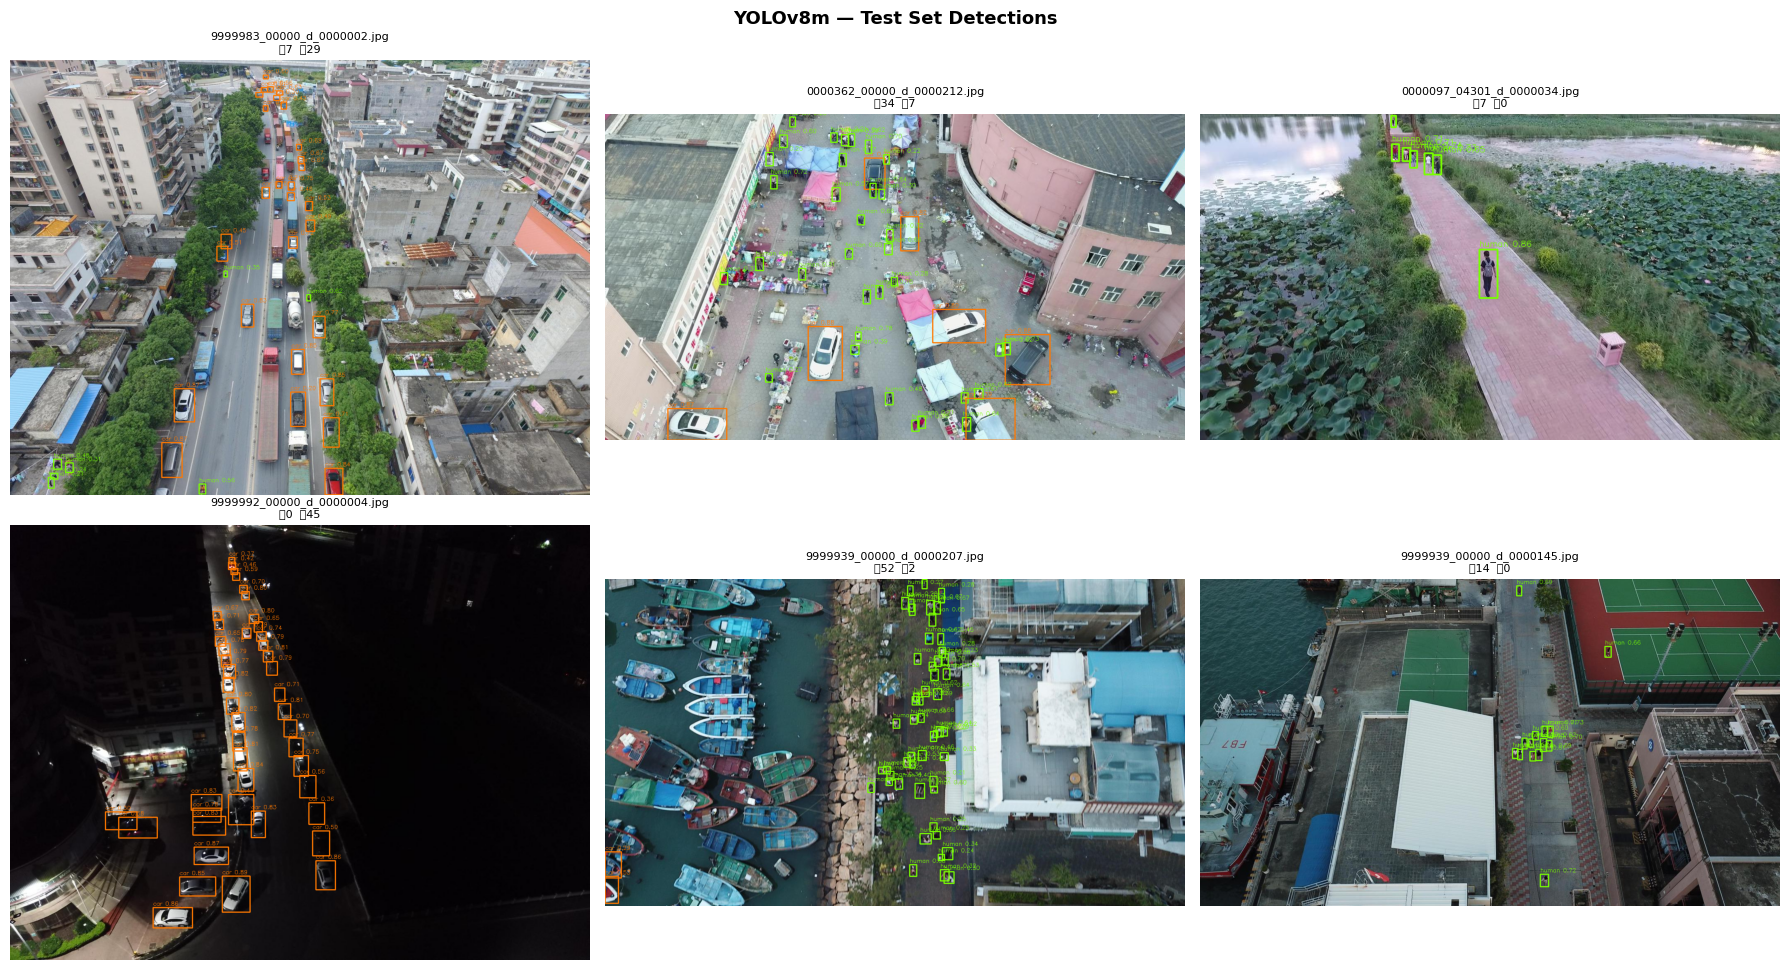

✅ Saved → test_results.png


In [9]:
# ============================================================
# CELL 6 — Visual Detection on Test Images
# ============================================================
# Run this whether or not you have label files

import random
random.seed(42)

sample = random.sample(test_images, min(6, len(test_images)))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, img_path in zip(axes.flatten(), sample):
    img = cv2.imread(str(img_path))
    results = detector(str(img_path), conf=CONF_THRESH,
                      iou=IOU_THRESH, verbose=False)[0]

    h_count = c_count = 0
    for box in results.boxes:
        cls_id = int(box.cls.item())
        conf_v = float(box.conf.item())
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        color = COLORS[cls_id]
        label = f"{CLASS_NAMES[cls_id]} {conf_v:.2f}"
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img, label, (x1, y1-5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
        if cls_id == 0: h_count += 1
        else: c_count += 1

    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{img_path.name}\n👤{h_count}  🚗{c_count}", fontsize=8)
    ax.axis("off")

plt.suptitle("YOLOv8m — Test Set Detections", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("test_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved → test_results.png")

In [13]:
from pathlib import Path
import shutil

# VisDrone original class mapping
# 0: pedestrian  → human
# 1: people      → human
# 2: bicycle     → SKIP
# 3: car         → car
# 4: van         → car
# 5: truck       → SKIP
# 6: tricycle    → SKIP
# 7: awning-tricycle → SKIP
# 8: bus         → SKIP
# 9: motor       → SKIP

YOLO_REMAP = {0: 0, 1: 0, 3: 1, 4: 1}

def remap_test_labels(src_label_dir, dst_label_dir):
    src_label_dir = Path(src_label_dir)
    dst_label_dir = Path(dst_label_dir)
    dst_label_dir.mkdir(parents=True, exist_ok=True)

    label_files = sorted(src_label_dir.glob("*.txt"))
    skipped = 0
    kept = 0

    for lbl_path in label_files:
        out_lines = []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls = int(parts[0])
                if cls not in YOLO_REMAP:
                    skipped += 1
                    continue
                new_cls = YOLO_REMAP[cls]
                out_lines.append(
                    f"{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}"
                )
                kept += 1

        # Save remapped label file
        with open(dst_label_dir / lbl_path.name, "w") as f:
            f.write("\n".join(out_lines))

    print(f"✅ Remapping done!")
    print(f"   Label files processed : {len(label_files)}")
    print(f"   Annotations kept      : {kept}  (human + car)")
    print(f"   Annotations skipped   : {skipped} (bike, bus, truck etc.)")

# ── Run it ──
remap_test_labels(
    src_label_dir = NEW_TEST_DATA_ROOT / "labels",      # your original labels
    dst_label_dir = NEW_TEST_DATA_ROOT / "labels_remapped"   # cleaned labels
)

✅ Remapping done!
   Label files processed : 1610
   Annotations kept      : 61227  (human + car)
   Annotations skipped   : 13875 (bike, bus, truck etc.)


In [14]:
import yaml

yaml_data = {
    "path"  : str(NEW_TEST_DATA_ROOT),
    "test"  : "images",
    "nc"    : 2,
    "names" : ["human", "car"]
}

with open("test.yaml", "w") as f:
    yaml.dump(yaml_data, f)

# Tell YOLO where remapped labels are
# Rename remapped folder to replace original
import shutil
shutil.rmtree(NEW_TEST_DATA_ROOT / "labels")
shutil.move(NEW_TEST_DATA_ROOT / "labels_remapped", NEW_TEST_DATA_ROOT / "labels")

print("✅ yaml ready, remapped labels in place")

✅ yaml ready, remapped labels in place
